Load revelant libraries:

In [1]:
import kagglehub
import os
import string
import unicodedata
import torch
import random
import math
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from collections import Counter

Load dataset:

In [2]:
path = kagglehub.dataset_download("yaminh/ai-generated-and-human-written-texts")
csv_file = os.path.join(path, "Ai_H_data.csv")

# using a subset (because full is too large)
data = pd.read_csv(csv_file, nrows=30000) #30k is good
data.head()

Using Colab cache for faster access to the 'ai-generated-and-human-written-texts' dataset.


,label,clean_text
0,0.0,cars cars have been around since they became f...
1,0.0,transportation is a large necessity in most co...
2,0.0,america s love affair with it s vehicles seems...
3,0.0,how often do you ride in a car do you drive a ...
4,0.0,cars are a wonderful thing they are perhaps on...


Check that data has a 50/50 split:

In [3]:
# number of rows that are human-generated
print(data[data["label"]==0.0].count())
# number of rows that are ai-generated
print(data[data["label"]==1.0].count())

label         16065
clean_text    16065
dtype: int64
label         13935
clean_text    13935
dtype: int64


### Step 1: Pre-process data

Orginally, I tried to use character to integer encoding but found it to be inefficent. Then I tried word to integer using Word2Vec but it was also too slow. Now, I am using nn.embedding for word to integer.

In [4]:
# convert text into word tokens
def tokenize(text):
    return text.lower().split()

In [5]:
# create tokenized corpus
tokenized_texts = [tokenize(text) for text in data["clean_text"]]

In [6]:
# build vocabulary
word_counts = Counter()

for tokens in tokenized_texts:
    word_counts.update(tokens)

# IGNORING THIS PART BC WE WANT TO KEEP TYPOS IN THE TEXT TO HELP CLASSIFY...
# if word shows up twice, then add to vocab: vocab = [word for word, count in word_counts.items() if count >= 2]
# helps remove typos
vocab = [word for word, count in word_counts.items() if count >= 1]

# reserve indices so start assigned indices start at 2
word_to_idx = {"<PAD>": 0, "<UNK>": 1} # pad is used for batching later, unk = unkown words, not in vocab

# assign indices to real words
for i, word in enumerate(vocab):
    word_to_idx[word] = i + 2

vocab_size = len(word_to_idx)
# used when creating embedding layer: self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

In [7]:
# convert text to tensor (maps tokens to indices)
def text_to_tensor(text):

    tokens = tokenize(text)
    indices = []

    for word in tokens:
        if word in word_to_idx:
            indices.append(word_to_idx[word])
        else:
            indices.append(word_to_idx["<UNK>"])

    return torch.tensor(indices, dtype=torch.long)

In [8]:
class EssayDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["clean_text"].tolist()
        self.labels = dataframe["label"].astype(int).tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        tensor = text_to_tensor(text)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return label, tensor

In [9]:
# pad sequences for batching, ensure essays (token indices vector) have same length
# this is because essays have different lengths and can crash without padding
def collate_fn(batch):
    labels, sequences = zip(*batch)
    sequences = pad_sequence(sequences, batch_first=True)
    labels = torch.stack(labels)
    return labels, sequences

In [10]:
dataset = EssayDataset(data)
train_set, test_set = torch.utils.data.random_split(dataset, [.80,.20], generator= torch.Generator().manual_seed(123))

In [11]:
# create dataloaders
train_loader = DataLoader(
    train_set,
    batch_size=64, # each training step sees 64 essays at once
    shuffle=True,
    num_workers=2, # use multiple CPU workers for loading data, preparing batches while the GPU trains
    pin_memory=True, # speeds up the transfer from CPU RAM to GPU VRAM
    collate_fn=collate_fn # ensures sequences get padded during batching
)

test_loader = DataLoader(
    test_set,
    batch_size=64,
    num_workers=2, # use multiple CPU workers for loading data, preparing batches while the GPU trains
    pin_memory=True, # speeds up the transfer from CPU RAM to GPU VRAM
    collate_fn=collate_fn
)

### Step 2: RNNs

Model evolution 1: single-layer RNN

Why?

*   Simple baseline to captures sequence information (order, context, relationship) without adding unnecessary complexity
*   Single layer can already learn useful sequential patterns (negation, stylistic cues)
*   Establishes performance benchmarks for comparing and evaluating improvements of more complex models
*   Text is sequential, so recurrent neural networks are commonly used as the first neural architecture for many NLP tasks [(Source)](https://nlp.stanford.edu/fsnlp/)
*   Because essays are long sequences -> choose larger hidden state to help retain more context (hidden size = model's memory capacity)
*   Simple RNNs struggle with long sequences due to vanishing gradients -> try LSTM next









In [12]:
# Set up RNN
import torch.nn as nn

class CharRNN1(nn.Module):
    def __init__(self, vocab_size, hidden_size, output_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, 128)
        self.rnn = nn.RNN(128, hidden_size, batch_first=True)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):

        embedded = self.embedding(line_tensor)

        rnn_out, hidden = self.rnn(embedded)

        output = self.h2o(hidden[0])
        output = self.softmax(output)

        return output


Training loop 1:

*   Mimics code in class -> super slow because we're processing/forward passing each essay in a batch one at a time
*   Almost behaves like batch_size = 1
*   80,000 essays x 50 epochs = 4,000,000 forward passes
*   Each forward pass must finish before  next begins -> sequential computation -> slow







In [13]:
# Original training loop
def train1(rnn, training_data, n_epoch = 10, batch_size = 64, report_every = 5, learning_rate = .1, criterion = nn.NLLLoss()):

    current_loss = 0
    all_losses = []
    rnn.train()
    optimizer = torch.optim.Adam(rnn.parameters(), lr = learning_rate)

    print(f'training on training set with {len(training_data)} observations')

    for iter in range(1, n_epoch + 1):
        rnn.zero_grad()
        batches = list(range(len(training_data)))
        random.shuffle(batches)
        batches = np.array_split(batches, len(batches)//batch_size)

        for idx,batch in enumerate(batches):
            batch_loss = 0
            for i in batch:
                (label, data_tensor, data_text) = training_data[i]
                output = rnn.forward(data_tensor)
                loss = criterion(output, label)
                batch_loss += loss

            batch_loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            current_loss += batch_loss.item()/len(batch)

        all_losses.append(current_loss / len(batches))
        if iter % report_every == 0:
            print(f'iteration: {iter}, average loss: {all_losses[-1]}')
        current_loss = 0

    return all_losses

Training loop 2:

*   Use Dataloader to automatically batch, shuffle, and efficiently load dataset
*   Groups dataset into batches of 64 -> 80,000 / 64 ≈ 1250 batches per epoch -> processes 64 essays in one forward pass instead of 64 separate passes
*   64 separate inputs combined into 1 tensor -> large matrix multiplication (which GPUs are optimized for: split work across many cores simultaneously) -> parallel computing -> faster





In [14]:
from torch.nn.utils.rnn import pack_padded_sequence

def train2(rnn, train_loader, test_loader, n_epoch = 10, report_every = 1, learning_rate = .1, criterion = nn.NLLLoss()):

    train_losses = []
    val_losses = []
    rnn.to(device)
    optimizer = torch.optim.Adam(rnn.parameters(), lr = learning_rate)

    print(f'training on training set with {len(train_loader)} observations')

    for iter in range(1, n_epoch + 1):

      rnn.train()
      train_loss = 0

      for idx, (label, data_tensor) in enumerate(train_loader):

          label = label.to(device)
          data_tensor = data_tensor.to(device)
          # data_tensor = data_tensor.squeeze(2)

          optimizer.zero_grad()

          # Compress the batch to ignore padding
          '''
          packed_input = pack_padded_sequence(
              data_tensor,
              lengths,
              batch_first=True,
              enforce_sorted=True
          )
          '''

          output = rnn(data_tensor) # feeds whole batch in
          loss = criterion(output, label)

          train_loss += loss.item()

          loss.backward()
          optimizer.step()

      train_losses.append(train_loss / len(train_loader)) #average loss for epoch

      rnn.eval()
      val_loss = 0

      with torch.no_grad():
          for idx, (label, data_tensor) in enumerate(test_loader):

              label = label.to(device)
              data_tensor = data_tensor.to(device)

              output = rnn(data_tensor)
              loss = criterion(output, label)

              val_loss += loss.item()

      val_losses.append(val_loss / len(test_loader))

      if iter % report_every == 0:
            print(f"epoch {iter} | train loss: {train_losses[-1]:.4f} | val loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses

In [15]:
torch.backends.cudnn.benchmark = True # automatically select the fastest GPU kernel for tensor shapes
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Note: character level-encoding required 28 mins for 1 epoch

In [16]:
rnn1 = CharRNN1(vocab_size, 128, 2)
rnn1 = rnn1.to(device)
train_losses, val_losses = train2(rnn1, train_loader, test_loader, n_epoch = 50, report_every = 1, learning_rate = 0.001, criterion = nn.NLLLoss()) #15 minutes for 50 epochs

training on training set with 375 observations
epoch 1 | train loss: 0.6915 | val loss: 0.6821
epoch 2 | train loss: 0.6852 | val loss: 0.6832
epoch 3 | train loss: 0.6852 | val loss: 0.6815
epoch 4 | train loss: 0.6879 | val loss: 0.6836
epoch 5 | train loss: 0.6845 | val loss: 0.6813
epoch 6 | train loss: 0.6843 | val loss: 0.6804
epoch 7 | train loss: 0.6833 | val loss: 0.6809
epoch 8 | train loss: 0.6848 | val loss: 0.6829
epoch 9 | train loss: 0.6850 | val loss: 0.6803
epoch 10 | train loss: 0.6840 | val loss: 0.6802
epoch 11 | train loss: 0.6855 | val loss: 0.6817
epoch 12 | train loss: 0.6837 | val loss: 0.6809
epoch 13 | train loss: 0.6841 | val loss: 0.6815
epoch 14 | train loss: 0.6835 | val loss: 0.6820
epoch 15 | train loss: 0.6834 | val loss: 0.6800
epoch 16 | train loss: 0.6847 | val loss: 0.6831
epoch 17 | train loss: 0.6846 | val loss: 0.6806
epoch 18 | train loss: 0.6853 | val loss: 0.6847
epoch 19 | train loss: 0.6838 | val loss: 0.6844
epoch 20 | train loss: 0.6856 |

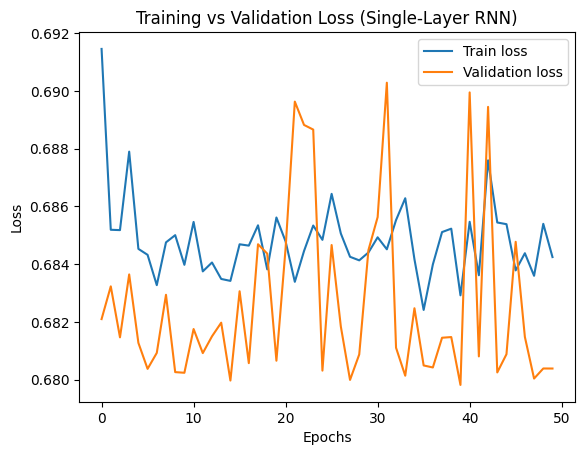

In [17]:
# Training loss curve
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")

plt.title("Training vs Validation Loss (Single-Layer RNN)")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [18]:
# Compute accuracy
def accuracy(dataloader, model):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for labels, data_tensors in dataloader:
            labels = labels.to(device)
            data_tensors = data_tensors.to(device)

            outputs = model(data_tensors)
            _, predicted_indices = torch.max(outputs, dim=1)

            correct += (predicted_indices == labels).sum().item()
            total += labels.size(0)

    return correct/total

In [19]:
accuracy(train_loader, rnn1)

0.534

In [20]:
accuracy(test_loader, rnn1)

0.5423333333333333

Model evolution 2: multi-layer RNN

Why?
*   Learn hierarchical language features (ie. word usage, syntax, stylistic cues <- helps detect AI vs. humans)
*   Captures longer contextual dependencies



In [21]:
# Set up RNN
import torch.nn as nn

class CharRNNm(nn.Module):
    def __init__(self, vocab_size, hidden_size, output_size, num_layers = 3, dropout=0.2):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, 128)
        self.rnn = nn.RNN(128, hidden_size, num_layers = num_layers, batch_first=True, dropout = dropout)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):

        embedded = self.embedding(line_tensor)

        rnn_out, hidden = self.rnn(embedded)

        output = self.h2o(hidden[-1])
        output = self.softmax(output)

        return output

In [22]:
rnn2 = CharRNNm(vocab_size, 128, 2)
rnn2 = rnn2.to(device)
train_losses, val_losses = train2(rnn2, train_loader, test_loader, n_epoch = 50, report_every = 1, learning_rate = 0.0001, criterion = nn.NLLLoss()) #15 minutes for 50 epochs

training on training set with 375 observations
epoch 1 | train loss: 0.6931 | val loss: 0.6899
epoch 2 | train loss: 0.6909 | val loss: 0.6909
epoch 3 | train loss: 0.6899 | val loss: 0.6858
epoch 4 | train loss: 0.6876 | val loss: 0.6844
epoch 5 | train loss: 0.6863 | val loss: 0.6838
epoch 6 | train loss: 0.6852 | val loss: 0.6823
epoch 7 | train loss: 0.6843 | val loss: 0.6831
epoch 8 | train loss: 0.6832 | val loss: 0.6864
epoch 9 | train loss: 0.6833 | val loss: 0.6808
epoch 10 | train loss: 0.6827 | val loss: 0.6847
epoch 11 | train loss: 0.6831 | val loss: 0.6805
epoch 12 | train loss: 0.6826 | val loss: 0.6805
epoch 13 | train loss: 0.6825 | val loss: 0.6807
epoch 14 | train loss: 0.6831 | val loss: 0.6801
epoch 15 | train loss: 0.6823 | val loss: 0.6797
epoch 16 | train loss: 0.6824 | val loss: 0.6811
epoch 17 | train loss: 0.6821 | val loss: 0.6823
epoch 18 | train loss: 0.7139 | val loss: 0.6888
epoch 19 | train loss: 0.6889 | val loss: 0.6844
epoch 20 | train loss: 0.6854 |

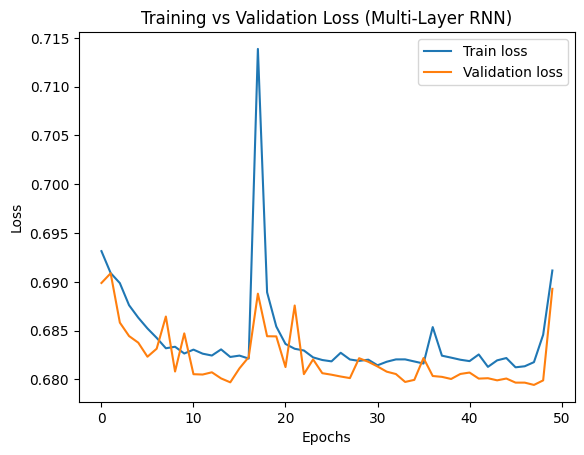

In [23]:
# Training loss curve
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")

plt.title("Training vs Validation Loss (Multi-Layer RNN)")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [24]:
accuracy(train_loader, rnn2)

0.534125

In [25]:
accuracy(test_loader, rnn2)

0.5426666666666666

@candy Add dropout to make it perform better and make learning rate even smaller to stablize

Use 1 layer to identify typo but adding more layers -> overanalyzing typos, which is pretty obvious

# Model 3: LSTM

In [26]:
# Model: BiLSTM text classifier

class TextLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=1, num_classes=2, dropout=0.2):
        super().__init__()

        # Token embedding lookup table (<PAD> index is ignored in gradients)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Bidirectional LSTM encoder over token embeddings
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=True,
        )

        # Regularization + final linear classification head
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, input_ids):
        # Compute true sequence lengths by counting non-pad tokens
        lengths = (input_ids != 0).sum(dim=1).clamp(min=1)

        # 1) Embed tokens, 2) run through BiLSTM
        x = self.embedding(input_ids)
        lstm_out, _ = self.lstm(x)

        # Select the last valid (non-padding) timestep per sequence
        idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, lstm_out.size(2))
        last_hidden = lstm_out.gather(1, idx).squeeze(1)

        # Apply dropout then map to logits for 2 classes
        logits = self.classifier(self.dropout(last_hidden))
        return logits


# Training and metric counter
def run_epoch(model, loader, optimizer, criterion, device, train=True):
    # Switch model behavior for dropout/batchnorm
    model.train() if train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    # Track gradients only in training mode
    with torch.set_grad_enabled(train):
        for labels, sequences in loader:
            # Move current batch to CPU/GPU
            labels = labels.to(device)
            sequences = sequences.to(device)

            # Forward pass and loss
            logits = model(sequences)
            loss = criterion(logits, labels)

            # Backward pass and parameter update (train only)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Accumulate running metrics
            total_loss += loss.item() * labels.size(0)
            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == labels).sum().item()
            total_count += labels.size(0)

    # Return average loss and accuracy over all examples
    avg_loss = total_loss / max(total_count, 1)
    avg_acc = total_correct / max(total_count, 1)
    return avg_loss, avg_acc


# Optional helper for quick experiments on random subsets
def make_small_loader(split, sample_size, batch_size=64, shuffle=True):
    # Sample up to sample_size indices from a split (without replacement)
    n = min(sample_size, len(split))
    indices = torch.randperm(len(split))[:n].tolist()
    subset = torch.utils.data.Subset(split, indices)
    return DataLoader(subset, batch_size=batch_size, shuffle=shuffle, collate_fn=collate_fn)


# quick_run controls whether to train on a smaller random subset
quick_run = False  # True: quick debug run, False: full train/test loaders
small_train_n = 500
small_test_n = 100
num_epochs = 20

# Choose loaders based on quick-run mode
if quick_run:
    train_loader_run = make_small_loader(train_set, small_train_n, batch_size=64, shuffle=True)
    test_loader_run = make_small_loader(test_set, small_test_n, batch_size=64, shuffle=False)
else:
    train_loader_run = train_loader
    test_loader_run = test_loader



# Model, loss, optimizer
model = TextLSTMClassifier(vocab_size=vocab_size, embed_dim=128, hidden_dim=128, num_layers=1, num_classes=2, dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=5e-4)


# Training loop with validation each epoch
train_loss_history = []
train_acc_history = []
val_loss_history = []
val_acc_history = []

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = run_epoch(model, train_loader_run, optimizer, criterion, device, train=True)
    val_loss, val_acc = run_epoch(model, test_loader_run, optimizer, criterion, device, train=False)

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    val_loss_history.append(val_loss)
    val_acc_history.append(val_acc)

    print(
        f"Epoch {epoch}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
    )

Epoch 1/20 | Train Loss: 0.4197, Train Acc: 0.8047 | Val Loss: 0.2856, Val Acc: 0.9058
Epoch 2/20 | Train Loss: 0.3006, Train Acc: 0.8826 | Val Loss: 0.1849, Val Acc: 0.9472
Epoch 3/20 | Train Loss: 0.3634, Train Acc: 0.8332 | Val Loss: 0.6648, Val Acc: 0.6762
Epoch 4/20 | Train Loss: 0.1684, Train Acc: 0.9444 | Val Loss: 0.1358, Val Acc: 0.9615
Epoch 5/20 | Train Loss: 0.1103, Train Acc: 0.9684 | Val Loss: 0.1302, Val Acc: 0.9613
Epoch 6/20 | Train Loss: 0.1384, Train Acc: 0.9571 | Val Loss: 0.1934, Val Acc: 0.9362
Epoch 7/20 | Train Loss: 0.2280, Train Acc: 0.9180 | Val Loss: 0.1744, Val Acc: 0.9380
Epoch 8/20 | Train Loss: 0.1165, Train Acc: 0.9629 | Val Loss: 0.1145, Val Acc: 0.9663
Epoch 9/20 | Train Loss: 0.0811, Train Acc: 0.9765 | Val Loss: 0.0900, Val Acc: 0.9732
Epoch 10/20 | Train Loss: 0.0566, Train Acc: 0.9846 | Val Loss: 0.0767, Val Acc: 0.9788
Epoch 11/20 | Train Loss: 0.0426, Train Acc: 0.9882 | Val Loss: 0.0663, Val Acc: 0.9808
Epoch 12/20 | Train Loss: 0.0323, Train A

##  LSTM Accuracy and Loss Plots

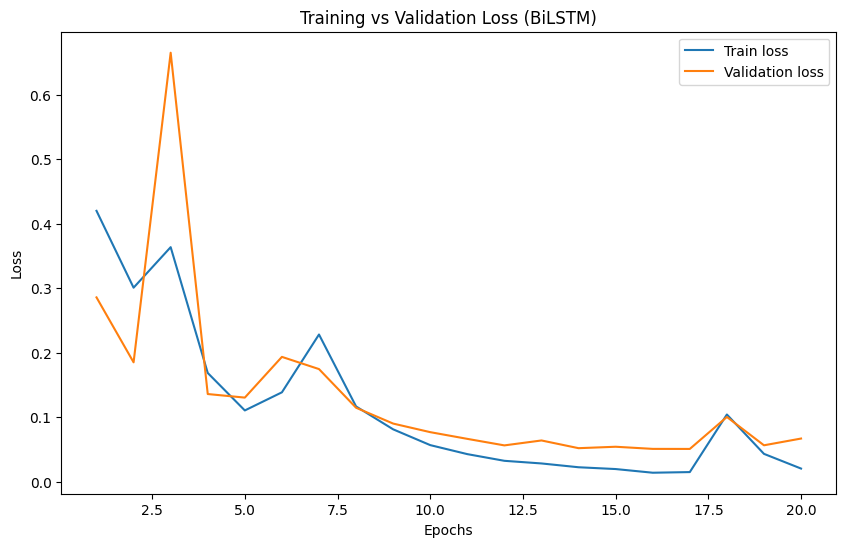

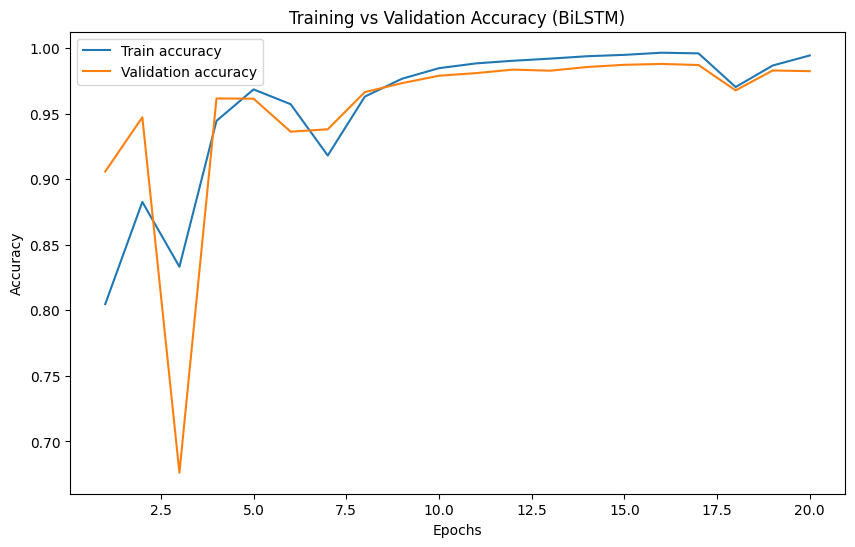

In [27]:
# Plot training vs validation loss and accuracy (no grid)

epochs = range(1, len(train_loss_history) + 1)

# Loss plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss_history, label="Train loss")
plt.plot(epochs, val_loss_history, label="Validation loss")
plt.title("Training vs Validation Loss (BiLSTM)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Accuracy plot
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_acc_history, label="Train accuracy")
plt.plot(epochs, val_acc_history, label="Validation accuracy")
plt.title("Training vs Validation Accuracy (BiLSTM)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Model 4: Auto-Encoder
## Model 4.1: RNN-Auto-Encoder

Model Architecture Description:
RNN/LSTM Autoencoder for Human vs AI Essay Classification

The model consists of three main components:

Encoder:

- Embedding layer converts word indices to dense vectors
- RNN/LSTM processes the sequence and produces hidden states
- Final hidden state captures the entire sequence representation

Decoder:

- Reconstructs the input sequence token by token
- Uses teacher forcing during training for stability
- Helps the model learn meaningful representations by forcing it to reconstruct the input

Classifier:

- Linear layer that takes the encoder's final hidden state
- Outputs logits for binary classification (human vs AI)

Training Strategy:

- Multi-task learning with weighted loss: α × classification_loss + (1-α) × reconstruction_loss
- The reconstruction task helps the model learn better representations of writing patterns
- Classification task directly optimizes for the target prediction

In [28]:
# 0. define encoder and decoder
class RNNAutoEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, num_classes=2, dropout=0.2):
        super().__init__()
        self.encoder = Encoder(vocab_size, embed_dim, hidden_dim, num_layers)
        self.decoder = Decoder(vocab_size, embed_dim, hidden_dim, num_layers)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, src, target=None, teacher_forcing_ratio=0.5):
        """
        src: (batch_size, src_len) - input sequences
        target: (batch_size, tgt_len) - target sequences for training
        """
        batch_size = src.size(0)
        src_len = src.size(1)

        # Encode
        encoder_outputs, encoder_hidden = self.encoder(src)

        # Use the final hidden state for classification
        # Take the last hidden state from the last layer
        final_hidden = encoder_hidden[-1]  # (batch_size, hidden_dim)

        # Classification logits
        classification_logits = self.classifier(final_hidden)

        # Reconstruction (for autoencoder loss)
        if target is not None:
            # Teacher forcing during training
            decoder_outputs = []
            decoder_hidden = encoder_hidden
            decoder_input = target[:, 0]  # Start token

            for t in range(1, target.size(1)):
                decoder_output, decoder_hidden = self.decoder(decoder_input, decoder_hidden)
                decoder_outputs.append(decoder_output)

                # Teacher forcing
                if torch.rand(1).item() < teacher_forcing_ratio:
                    decoder_input = target[:, t]
                else:
                    decoder_input = decoder_output.argmax(dim=1)

            reconstruction_logits = torch.stack(decoder_outputs, dim=1)
            return classification_logits, reconstruction_logits
        else:
            # Inference mode - just return classification
            return classification_logits

class Encoder(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

    def forward(self, src):
        """
        src: (batch_size, src_len)
        """
        embedded = self.embedding(src)  # (batch_size, src_len, embed_dim)
        outputs, hidden = self.rnn(embedded)
        # outputs: (batch_size, src_len, hidden_dim)
        # hidden: (num_layers, batch_size, hidden_dim)
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_token, hidden):
        """
        input_token: (batch_size,)
        hidden: (num_layers, batch_size, hidden_dim)
        """
        input_token = input_token.unsqueeze(1)  # (batch_size, 1)
        embedded = self.embedding(input_token)  # (batch_size, 1, embed_dim)
        output, hidden = self.rnn(embedded, hidden)  # output: (batch_size, 1, hidden_dim)
        prediction = self.fc_out(output.squeeze(1))  # (batch_size, output_dim)
        return prediction, hidden


# 1. SAFE DATALOADER SETUP (prevents multiprocessing crashes)
def create_safe_dataloader(dataset, batch_size=64, shuffle=True):
    """Create crash-resistant DataLoader for Jupyter"""
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,  # Prevents multiprocessing crashes
        pin_memory=False,  # MPS compatibility
        collate_fn=collate_fn
    )

# 2. MEMORY-EFFICIENT TRAINING FUNCTION
def train_rnn_autoencoder_safe(embed_dim=32, hidden_dim=64, num_layers=1, dropout=0.2, num_epochs=5, batch_size=64, lr=1e-3):
    """Memory-efficient training with crash prevention"""

    # Device setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Delete previously created models to free up GPU memory
    if 'rnn1' in globals() and isinstance(globals()['rnn1'], nn.Module):
        del globals()['rnn1']
    if 'rnn2' in globals() and isinstance(globals()['rnn2'], nn.Module):
        del globals()['rnn2']
    # The transformer model - fix UnboundLocalError by checking global scope
    if 'model' in globals() and isinstance(globals()['model'], nn.Module):
        del globals()['model']
    torch.cuda.empty_cache()
    print("Cleared GPU memory from previous models.")

    # Create safe DataLoaders
    train_loader_safe = create_safe_dataloader(train_set, batch_size=batch_size, shuffle=True)
    test_loader_safe = create_safe_dataloader(test_set, batch_size=batch_size, shuffle=False)

    # Initialize model with proper dropout
    model = RNNAutoEncoder(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        num_classes=2,
        dropout=dropout
    ).to(device)

    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Loss functions
    classification_criterion = nn.CrossEntropyLoss()
    reconstruction_criterion = nn.CrossEntropyLoss(ignore_index=0)

    # Optimizer with gradient clipping
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    # Storage for metrics
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    print("Starting training...")

    for epoch in range(1, num_epochs + 1):
        try:
            # Clear cache to prevent memory buildup
            if device.type == 'cuda':
                torch.cuda.empty_cache()

            # Training epoch
            train_loss, train_acc = run_epoch_autoencoder_safe(
                model, train_loader_safe, optimizer,
                classification_criterion, reconstruction_criterion,
                device, train=True, alpha=0.8  # Higher weight on classification
            )

            # Validation epoch
            val_loss, val_acc = run_epoch_autoencoder_safe(
                model, test_loader_safe, optimizer,
                classification_criterion, reconstruction_criterion,
                device, train=False, alpha=0.8
            )

            # Store metrics
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)

            print(f"Epoch {epoch}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

            # Early stopping if loss explodes
            if train_loss > 10.0:
                print("Training loss exploded, stopping early")
                break

        except Exception as e:
            print(f"Error in epoch {epoch}: {e}")
            print("Attempting to continue...")
            continue

    return model, {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }

# 4. UPDATED run_epoch_autoencoder WITH GRADIENT CLIPPING
def run_epoch_autoencoder_safe(model, loader, optimizer, classification_criterion,
                               reconstruction_criterion, device, train=True, alpha=0.7):
    """Safe training epoch with gradient clipping"""
    model.train() if train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.set_grad_enabled(train):
        for batch_idx, (labels, sequences) in enumerate(loader):
            try:
                labels = labels.to(device)
                sequences = sequences.to(device)

                if sequences.size(1) > 150:  # truncate very long sequences
                    sequences = sequences[:, :150]  # Truncate

                if train: # training mode
                    classification_logits, reconstruction_logits = model(sequences, sequences)

                    # Classification loss
                    classification_loss = classification_criterion(classification_logits, labels)

                    # Reconstruction loss (excluding first token)
                    reconstruction_targets = sequences[:, 1:].contiguous().view(-1)
                    reconstruction_outputs = reconstruction_logits.contiguous().view(-1, reconstruction_logits.size(-1))
                    reconstruction_loss = reconstruction_criterion(reconstruction_outputs, reconstruction_targets)

                    # Combined loss
                    loss = alpha * classification_loss + (1 - alpha) * reconstruction_loss
                else: # evaluation mode
                    classification_logits = model(sequences)
                    loss = classification_criterion(classification_logits, labels)

                if train:
                    optimizer.zero_grad()
                    loss.backward()

                    # Gradient clipping to prevent exploding gradients
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                    optimizer.step()

                total_loss += loss.item() * labels.size(0)
                preds = torch.argmax(classification_logits, dim=1)
                total_correct += (preds == labels).sum().item()
                total_count += labels.size(0)

            except RuntimeError as e:
                if "out of memory" in str(e):
                    print(f"OOM error in batch {batch_idx}, skipping...")
                    if device.type == 'cuda':
                        torch.cuda.empty_cache()
                    continue
                else:
                    raise e

    avg_loss = total_loss / max(total_count, 1)
    avg_acc = total_correct / max(total_count, 1)
    return avg_loss, avg_acc

In [29]:
# Set parameters and run the model
embed_dim = 32
hidden_dim = 64
num_layers = 1
dropout = 0.2
num_epochs = 10
batch_size = 64
lr = 1e-3

print("Starting crash-resistant RNN autoencoder training...")
model, metrics = train_rnn_autoencoder_safe(
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout,
    num_epochs=num_epochs,
    batch_size=batch_size,
    lr=lr
)

Starting crash-resistant RNN autoencoder training...
Using device: cuda
Cleared GPU memory from previous models.
Model parameters: 9,150,776
Starting training...
Epoch 1/10 | Train Loss: 1.8681, Train Acc: 0.7242 | Val Loss: 0.4394, Val Acc: 0.8260
Epoch 2/10 | Train Loss: 1.6336, Train Acc: 0.8569 | Val Loss: 0.3329, Val Acc: 0.8822
Epoch 3/10 | Train Loss: 1.5557, Train Acc: 0.9014 | Val Loss: 0.2330, Val Acc: 0.9252
Epoch 4/10 | Train Loss: 1.5024, Train Acc: 0.9273 | Val Loss: 0.2071, Val Acc: 0.9330
Epoch 5/10 | Train Loss: 1.4647, Train Acc: 0.9433 | Val Loss: 0.1734, Val Acc: 0.9483
Epoch 6/10 | Train Loss: 1.4344, Train Acc: 0.9570 | Val Loss: 0.2187, Val Acc: 0.9338
Epoch 7/10 | Train Loss: 1.4142, Train Acc: 0.9607 | Val Loss: 0.1390, Val Acc: 0.9595
Epoch 8/10 | Train Loss: 1.3820, Train Acc: 0.9670 | Val Loss: 0.1696, Val Acc: 0.9473
Epoch 9/10 | Train Loss: 1.3542, Train Acc: 0.9716 | Val Loss: 0.1322, Val Acc: 0.9632
Epoch 10/10 | Train Loss: 1.3278, Train Acc: 0.9772 | V

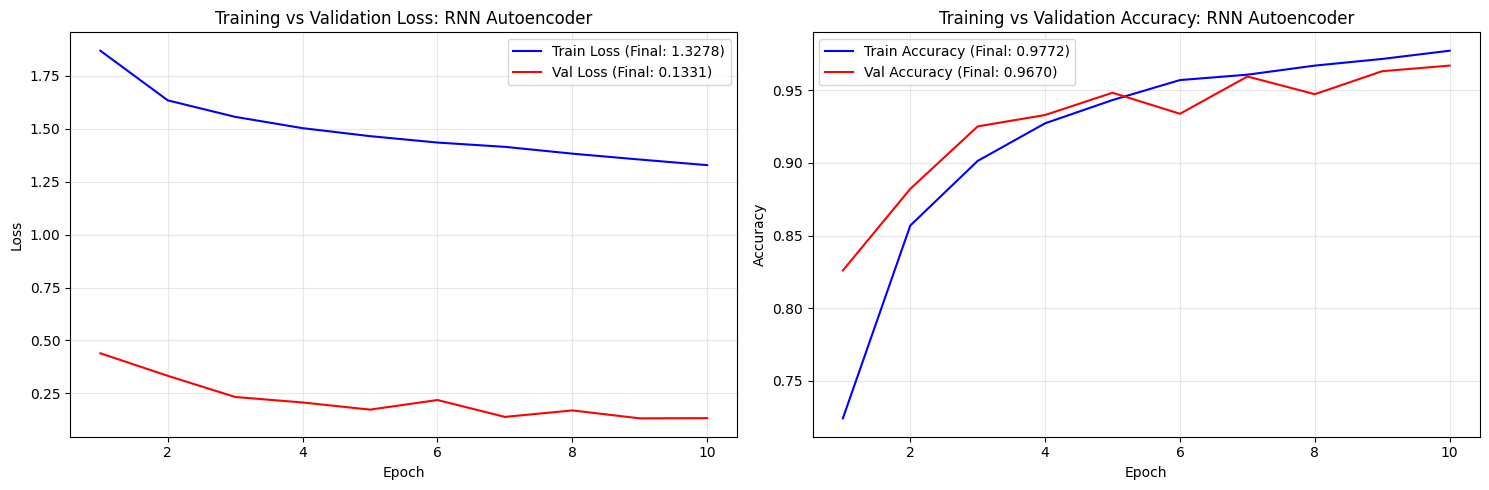

Final Train Accuracy: 0.9772
Final Test/Validation Accuracy: 0.9670


In [30]:
import matplotlib.pyplot as plt

def plot_training_results(train_losses, val_losses, train_accs, val_accs):
    """Plot training metrics"""
    epochs = range(1, len(train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss plot
    ax1.plot(epochs, train_losses, 'b-', label=f'Train Loss (Final: {train_losses[-1]:.4f})')
    ax1.plot(epochs, val_losses, 'r-', label=f'Val Loss (Final: {val_losses[-1]:.4f})')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training vs Validation Loss: RNN Autoencoder')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2.plot(epochs, train_accs, 'b-', label=f'Train Accuracy (Final: {train_accs[-1]:.4f})')
    ax2.plot(epochs, val_accs, 'r-', label=f'Val Accuracy (Final: {val_accs[-1]:.4f})')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training vs Validation Accuracy: RNN Autoencoder')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if metrics and 'train_losses' in metrics and len(metrics['train_losses']) > 0:
    # Plot training metrics including loss and accuracy
    plot_training_results(
        metrics['train_losses'],
        metrics['val_losses'],
        metrics['train_accs'],
        metrics['val_accs']
    )
    # Report final train and test accuracy via print
    print(f"Final Train Accuracy: {metrics['train_accs'][-1]:.4f}")
    print(f"Final Test/Validation Accuracy: {metrics['val_accs'][-1]:.4f}")
else:
    print("No metrics available to plot.")

## Model 4.2: LSTM-Auto-Encoder

In [31]:
#   LSTM-auto-encoder
# 0. define encoder and decoder
class LSTMAutoEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, num_classes=2, dropout=0.2):
        super().__init__()
        self.encoder = Encoder(vocab_size, embed_dim, hidden_dim, num_layers)
        self.decoder = Decoder(vocab_size, embed_dim, hidden_dim, num_layers)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, src, target=None, teacher_forcing_ratio=0.5):
        """
        src: (batch_size, src_len) - input sequences
        target: (batch_size, tgt_len) - target sequences for training
        """
        batch_size = src.size(0)
        src_len = src.size(1)

        # Encode
        encoder_outputs, encoder_hidden = self.encoder(src)

        # Use the final hidden state for classification
        # Take the last hidden state from the last layer
        if isinstance(encoder_hidden, tuple):
            final_hidden = encoder_hidden[0][-1]
        else:
            final_hidden = encoder_hidden[-1]  # (batch_size, hidden_dim)

        # Classification logits
        classification_logits = self.classifier(final_hidden)

        # Reconstruction (for autoencoder loss)
        if target is not None:
            # Teacher forcing during training
            decoder_outputs = []
            decoder_hidden = encoder_hidden
            decoder_input = target[:, 0]  # Start token

            for t in range(1, target.size(1)):
                decoder_output, decoder_hidden = self.decoder(decoder_input, decoder_hidden)
                decoder_outputs.append(decoder_output)

                # Teacher forcing
                if torch.rand(1).item() < teacher_forcing_ratio:
                    decoder_input = target[:, t]
                else:
                    decoder_input = decoder_output.argmax(dim=1)

            reconstruction_logits = torch.stack(decoder_outputs, dim=1)
            return classification_logits, reconstruction_logits
        else:
            # Inference mode - just return classification
            return classification_logits

class Encoder(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

    def forward(self, src):
        """
        src: (batch_size, src_len)
        """
        embedded = self.embedding(src)  # (batch_size, src_len, embed_dim)
        outputs, hidden = self.lstm(embedded)
        # outputs: (batch_size, src_len, hidden_dim)
        # hidden: (h_n, c_n) where each is (num_layers, batch_size, hidden_dim)
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_token, hidden):
        """
        input_token: (batch_size,)
        hidden: (h_n, c_n) where each is (num_layers, batch_size, hidden_dim)
        """
        input_token = input_token.unsqueeze(1)  # (batch_size, 1)
        embedded = self.embedding(input_token)  # (batch_size, 1, embed_dim)
        output, hidden = self.lstm(embedded, hidden)  # output: (batch_size, 1, hidden_dim)
        prediction = self.fc_out(output.squeeze(1))  # (batch_size, output_dim)
        return prediction, hidden


# 1. SAFE DATALOADER SETUP (prevents multiprocessing crashes)
def create_safe_dataloader(dataset, batch_size=64, shuffle=True):
    """Create crash-resistant DataLoader for Jupyter"""
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,  # Prevents multiprocessing crashes
        pin_memory=False,  # MPS compatibility
        collate_fn=collate_fn
    )

# 2. MEMORY-EFFICIENT TRAINING FUNCTION
def train_lstm_autoencoder_safe(embed_dim=32, hidden_dim=64, num_layers=1, dropout=0.2, num_epochs=5, batch_size=64, lr=1e-3):
    """Memory-efficient training with crash prevention"""

    # Device setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Delete previously created models to free up GPU memory
    if 'rnn1' in globals() and isinstance(globals()['rnn1'], nn.Module):
        del globals()['rnn1']
    if 'rnn2' in globals() and isinstance(globals()['rnn2'], nn.Module):
        del globals()['rnn2']
    # The transformer model - fix UnboundLocalError by checking global scope
    if 'model' in globals() and isinstance(globals()['model'], nn.Module):
        del globals()['model']
    torch.cuda.empty_cache()
    print("Cleared GPU memory from previous models.")

    # Create safe DataLoaders
    train_loader_safe = create_safe_dataloader(train_set, batch_size=batch_size, shuffle=True)
    test_loader_safe = create_safe_dataloader(test_set, batch_size=batch_size, shuffle=False)

    # Initialize model with proper dropout
    model = LSTMAutoEncoder(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        num_classes=2,
        dropout=dropout
    ).to(device)

    print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

    # Loss functions
    classification_criterion = nn.CrossEntropyLoss()
    reconstruction_criterion = nn.CrossEntropyLoss(ignore_index=0)

    # Optimizer with gradient clipping
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    # Storage for metrics
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    print("Starting training...")

    for epoch in range(1, num_epochs + 1):
        try:
            # Clear cache to prevent memory buildup
            if device.type == 'cuda':
                torch.cuda.empty_cache()

            # Training epoch
            train_loss, train_acc = run_epoch_autoencoder_safe(
                model, train_loader_safe, optimizer,
                classification_criterion, reconstruction_criterion,
                device, train=True, alpha=0.8  # Higher weight on classification
            )

            # Validation epoch
            val_loss, val_acc = run_epoch_autoencoder_safe(
                model, test_loader_safe, optimizer,
                classification_criterion, reconstruction_criterion,
                device, train=False, alpha=0.8
            )

            # Store metrics
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)

            print(f"Epoch {epoch}/{num_epochs} | "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

            # Early stopping if loss explodes
            if train_loss > 10.0:
                print("Training loss exploded, stopping early")
                break

        except Exception as e:
            print(f"Error in epoch {epoch}: {e}")
            print("Attempting to continue...")
            continue

    return model, {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs
    }

# 4. UPDATED run_epoch_autoencoder WITH GRADIENT CLIPPING
def run_epoch_autoencoder_safe(model, loader, optimizer, classification_criterion,
                               reconstruction_criterion, device, train=True, alpha=0.7):
    """Safe training epoch with gradient clipping"""
    model.train() if train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.set_grad_enabled(train):
        for batch_idx, (labels, sequences) in enumerate(loader):
            try:
                labels = labels.to(device)
                sequences = sequences.to(device)

                if sequences.size(1) > 150:  # truncate very long sequences
                    sequences = sequences[:, :150]  # Truncate

                if train: # training mode
                    classification_logits, reconstruction_logits = model(sequences, sequences)

                    # Classification loss
                    classification_loss = classification_criterion(classification_logits, labels)

                    # Reconstruction loss (excluding first token)
                    reconstruction_targets = sequences[:, 1:].contiguous().view(-1)
                    reconstruction_outputs = reconstruction_logits.contiguous().view(-1, reconstruction_logits.size(-1))
                    reconstruction_loss = reconstruction_criterion(reconstruction_outputs, reconstruction_targets)

                    # Combined loss
                    loss = alpha * classification_loss + (1 - alpha) * reconstruction_loss
                else: # evaluation mode
                    classification_logits = model(sequences)
                    loss = classification_criterion(classification_logits, labels)

                if train:
                    optimizer.zero_grad()
                    loss.backward()

                    # Gradient clipping to prevent exploding gradients
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

                    optimizer.step()

                total_loss += loss.item() * labels.size(0)
                preds = torch.argmax(classification_logits, dim=1)
                total_correct += (preds == labels).sum().item()
                total_count += labels.size(0)

            except RuntimeError as e:
                if "out of memory" in str(e):
                    print(f"OOM error in batch {batch_idx}, skipping...")
                    if device.type == 'cuda':
                        torch.cuda.empty_cache()
                    continue
                else:
                    raise e

    avg_loss = total_loss / max(total_count, 1)
    avg_acc = total_correct / max(total_count, 1)
    return avg_loss, avg_acc

In [32]:
import gc
gc.collect()
# torch.cuda.empty_cache()

# Set parameters and run the model
embed_dim = 32
hidden_dim = 64
num_layers = 1
dropout = 0.3
num_epochs = 10
batch_size = 32
lr = 1e-3

# Clean up any existing model to free memory
if 'model' in globals():
    del model
import gc
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Starting LSTM autoencoder training...")
model, metrics = train_lstm_autoencoder_safe(
    embed_dim=embed_dim,
    hidden_dim=hidden_dim,
    num_layers=num_layers,
    dropout=dropout,
    num_epochs=num_epochs,
    batch_size=batch_size,
    lr=lr
)

Starting LSTM autoencoder training...
Using device: cuda
Cleared GPU memory from previous models.
Model parameters: 9,188,408
Starting training...
Epoch 1/10 | Train Loss: 1.6994, Train Acc: 0.8255 | Val Loss: 0.2014, Val Acc: 0.9327
Epoch 2/10 | Train Loss: 1.4520, Train Acc: 0.9499 | Val Loss: 0.1167, Val Acc: 0.9618
Epoch 3/10 | Train Loss: 1.4010, Train Acc: 0.9716 | Val Loss: 0.1056, Val Acc: 0.9752
Epoch 4/10 | Train Loss: 1.3755, Train Acc: 0.9807 | Val Loss: 0.0757, Val Acc: 0.9780
Epoch 5/10 | Train Loss: 1.3403, Train Acc: 0.9850 | Val Loss: 0.0757, Val Acc: 0.9807
Epoch 6/10 | Train Loss: 1.3171, Train Acc: 0.9910 | Val Loss: 0.0781, Val Acc: 0.9793
Epoch 7/10 | Train Loss: 1.3069, Train Acc: 0.9928 | Val Loss: 0.0566, Val Acc: 0.9822
Epoch 8/10 | Train Loss: 1.2951, Train Acc: 0.9940 | Val Loss: 0.0827, Val Acc: 0.9772
Epoch 9/10 | Train Loss: 1.2774, Train Acc: 0.9945 | Val Loss: 0.0675, Val Acc: 0.9827
Epoch 10/10 | Train Loss: 1.2638, Train Acc: 0.9955 | Val Loss: 0.0574

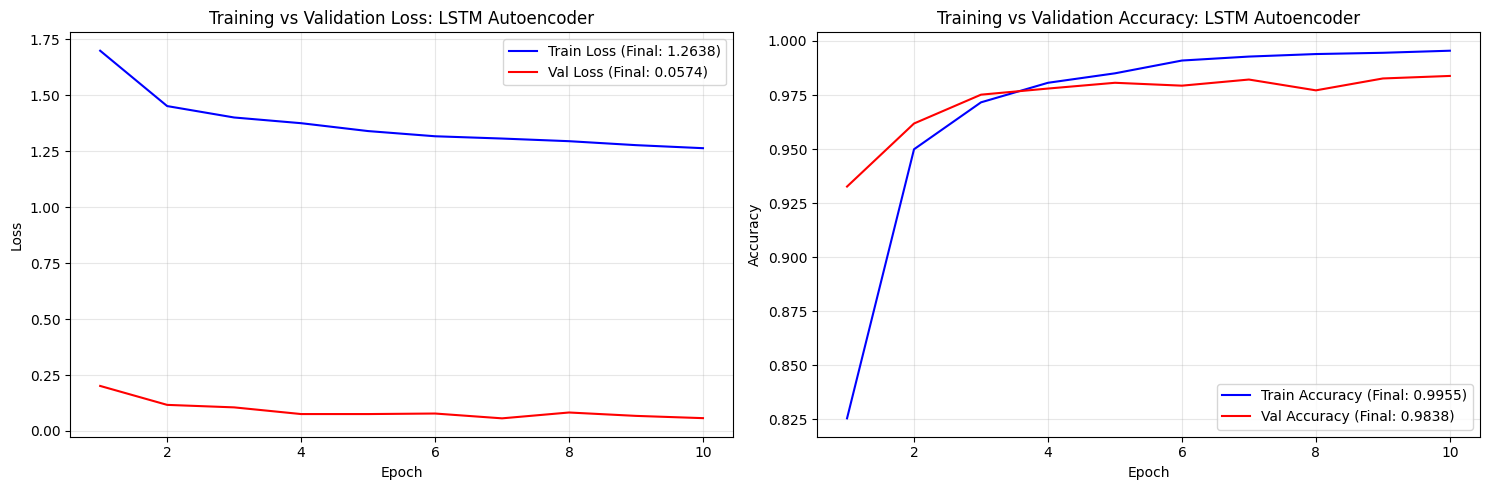

Final Train Accuracy: 0.9955
Final Test/Validation Accuracy: 0.9838


In [33]:
import matplotlib.pyplot as plt

def plot_training_results(train_losses, val_losses, train_accs, val_accs):
    """Plot training metrics"""
    epochs = range(1, len(train_losses) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss plot
    ax1.plot(epochs, train_losses, 'b-', label=f'Train Loss (Final: {train_losses[-1]:.4f})')
    ax1.plot(epochs, val_losses, 'r-', label=f'Val Loss (Final: {val_losses[-1]:.4f})')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training vs Validation Loss: LSTM Autoencoder')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy plot
    ax2.plot(epochs, train_accs, 'b-', label=f'Train Accuracy (Final: {train_accs[-1]:.4f})')
    ax2.plot(epochs, val_accs, 'r-', label=f'Val Accuracy (Final: {val_accs[-1]:.4f})')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training vs Validation Accuracy: LSTM Autoencoder')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

if metrics and 'train_losses' in metrics and len(metrics['train_losses']) > 0:
    # Plot training metrics including loss and accuracy
    plot_training_results(
        metrics['train_losses'],
        metrics['val_losses'],
        metrics['train_accs'],
        metrics['val_accs']
    )
    # Report final train and test accuracy via print
    print(f"Final Train Accuracy: {metrics['train_accs'][-1]:.4f}")
    print(f"Final Test/Validation Accuracy: {metrics['val_accs'][-1]:.4f}")
else:
    print("No metrics available to plot.")


### Transformer code (30k sample size)

- took around 3-4 min for the each epoch to give result (use T4 GPU)
- test acc slightly higher than train acc (for now)
- total runtime:  34 min for 10 epoch
- valid acc:  0.9833 (may have the potential of increasing; slightly smaller than accuracy for 100k sample size)

In [34]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=2000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)
    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return x

class TransformerClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=256,
        num_heads=8,
        hidden_dim=512,
        num_layers=2,
        num_classes=2,
        dropout = 0.1
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
        self.pos_encoder = PositionalEncoding(embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        batch_size = x.size(0)
        x = self.embedding(x)
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = self.pos_encoder(x)
        padding_mask = (x[:,:,0] == 0)
        x = self.transformer(x)
        cls_output = x[:,0]
        x = self.dropout(cls_output)
        return self.fc(x)


Transformer architecture:

- embedding layer (token index to vector)
- postiional encoding
- transformer encoder layer
- pooling
- linear classifier

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerClassifier(vocab_size).to(device)

In [36]:
# training loop
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5, weight_decay=1e-4)
def train(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for labels, texts in loader:
        texts = texts.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

In [37]:
# evaluation
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for labels, texts in loader:
            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

In [38]:
train_losses = []
train_accs = []
valid_losses = []
valid_accs = []
epochs = 10
for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader)
    valid_loss, valid_acc = evaluate(model, test_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)

    print(f"Epoch {epoch+1}")
    print("Train Loss:", train_loss)
    print("Train Acc:", train_acc)
    print("Valid Loss:", valid_loss)
    print("Valid Acc:", valid_acc)
    print()

Epoch 1
Train Loss: 0.48349352451165517
Train Acc: 0.74275
Valid Loss: 0.24475299654171823
Valid Acc: 0.9006666666666666

Epoch 2
Train Loss: 0.20744782894849778
Train Acc: 0.918375
Valid Loss: 0.18014478917293092
Valid Acc: 0.932

Epoch 3
Train Loss: 0.14125342565774918
Train Acc: 0.9488333333333333
Valid Loss: 0.14585310280164507
Valid Acc: 0.9451666666666667

Epoch 4
Train Loss: 0.10379977065324783
Train Acc: 0.9639166666666666
Valid Loss: 0.09564889515651033
Valid Acc: 0.9666666666666667

Epoch 5
Train Loss: 0.0886387323041757
Train Acc: 0.9672083333333333
Valid Loss: 0.09600472354151784
Valid Acc: 0.9648333333333333

Epoch 6
Train Loss: 0.07189131257931392
Train Acc: 0.9742916666666667
Valid Loss: 0.07181102700749452
Valid Acc: 0.974

Epoch 7
Train Loss: 0.06267749811460574
Train Acc: 0.9778333333333333
Valid Loss: 0.08225693926215172
Valid Acc: 0.9696666666666667

Epoch 8
Train Loss: 0.05918787123759588
Train Acc: 0.978
Valid Loss: 0.06528095984980067
Valid Acc: 0.976166666666666

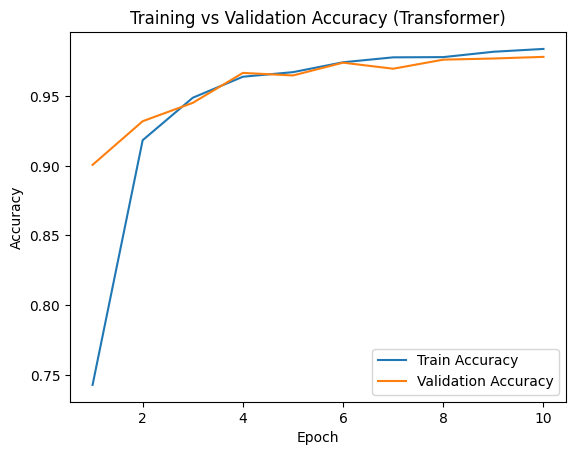

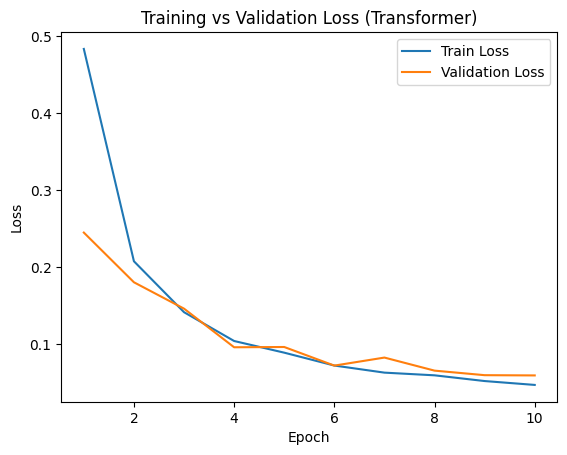

In [39]:
import matplotlib.pyplot as plt
epochs_range = range(1, epochs + 1)

# Accuracy plot
plt.figure()
plt.plot(epochs_range, train_accs, label="Train Accuracy")
plt.plot(epochs_range, valid_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Transformer)")
plt.legend()
plt.show()

# Loss plot
plt.figure()
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, valid_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Transformer)")
plt.legend()
plt.show()

### Character Based CNN
googled code reference, just for extension

In [40]:
# build character vocabulary
all_text = " ".join(data["clean_text"].tolist())
chars = sorted(list(set(all_text)))
# assign indices starting from 1
char_to_idx = {c: i+1 for i, c in enumerate(chars)}
vocab_size = len(char_to_idx) + 1   # +1 because 0 will be used for padding
print("Character vocab size:", vocab_size)

Character vocab size: 28


In [41]:
# convert text to character indices
max_length = 1000   # limit essay length
def text_to_tensor(text):
    indices = []
    for ch in text[:max_length]:
        if ch in char_to_idx:
            indices.append(char_to_idx[ch])
        else:
            indices.append(char_to_idx["<UNK>"])
    return torch.tensor(indices, dtype=torch.long)

In [42]:
class CharEssayDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["clean_text"].tolist()
        self.labels = dataframe["label"].astype(int).tolist()
    def __len__(self):
        return len(self.texts)
    def __getitem__(self, idx):
        text = self.texts[idx]
        tensor = text_to_char_tensor(text)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return label, tensor

In [43]:
class CharCNN(nn.Module):

    def __init__(self, vocab_size, embed_dim=64, num_classes=2):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.conv1 = nn.Conv1d(embed_dim, 128, kernel_size=7, padding=3)
        self.conv2 = nn.Conv1d(128, 128, kernel_size=5, padding=2)
        self.conv3 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(3)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):

        # x shape: (batch, seq_len)
        x = self.embedding(x)
        # convert to (batch, channels, seq_len)
        x = x.transpose(1,2)
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = self.relu(self.conv3(x))
        # global max pooling
        x = torch.max(x, dim=2)[0]
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [44]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CharCNN(vocab_size).to(device)

In [45]:
# training loop
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
def train(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for labels, texts in loader:
        texts = texts.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

In [46]:
# evaluation
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for labels, texts in loader:
            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total

In [47]:
train_losses = []
train_accs = []
valid_losses = []
valid_accs = []
epochs = 10
for epoch in range(epochs):
    train_loss, train_acc = train(model, train_loader)
    valid_loss, valid_acc = evaluate(model, test_loader)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    valid_losses.append(valid_loss)
    valid_accs.append(valid_acc)

    print(f"Epoch {epoch+1}")
    print("Train Loss:", train_loss)
    print("Train Acc:", train_acc)
    print("Valid Loss:", valid_loss)
    print("Valid Acc:", valid_acc)
    print()

Epoch 1
Train Loss: 0.36562509151299794
Train Acc: 0.8179583333333333
Valid Loss: 0.24049927088174414
Valid Acc: 0.9045

Epoch 2
Train Loss: 0.16378928659359615
Train Acc: 0.9409583333333333
Valid Loss: 0.1222527904951192
Valid Acc: 0.9588333333333333

Epoch 3
Train Loss: 0.11012423498928547
Train Acc: 0.96025
Valid Loss: 0.1108589369328098
Valid Acc: 0.9605

Epoch 4
Train Loss: 0.0791875474229455
Train Acc: 0.9726666666666667
Valid Loss: 0.1092995591065351
Valid Acc: 0.9628333333333333

Epoch 5
Train Loss: 0.06875634383782744
Train Acc: 0.9752083333333333
Valid Loss: 0.09120353179528042
Valid Acc: 0.9683333333333334

Epoch 6
Train Loss: 0.05277975378930569
Train Acc: 0.980875
Valid Loss: 0.13225146206690275
Valid Acc: 0.955

Epoch 7
Train Loss: 0.04564909027237445
Train Acc: 0.98375
Valid Loss: 0.10588038528456967
Valid Acc: 0.9658333333333333

Epoch 8
Train Loss: 0.04091215391286338
Train Acc: 0.9858333333333333
Valid Loss: 0.09643828234774002
Valid Acc: 0.9695

Epoch 9
Train Loss: 0

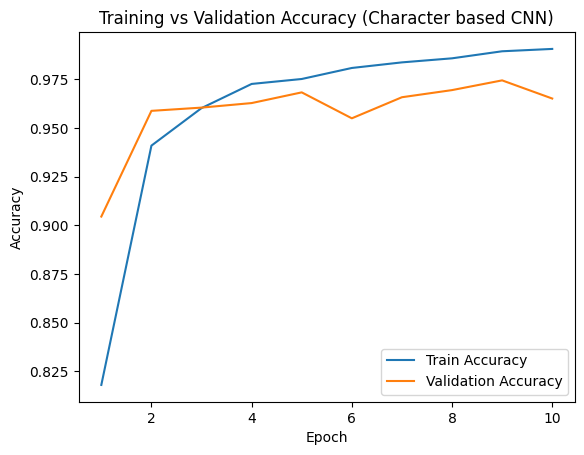

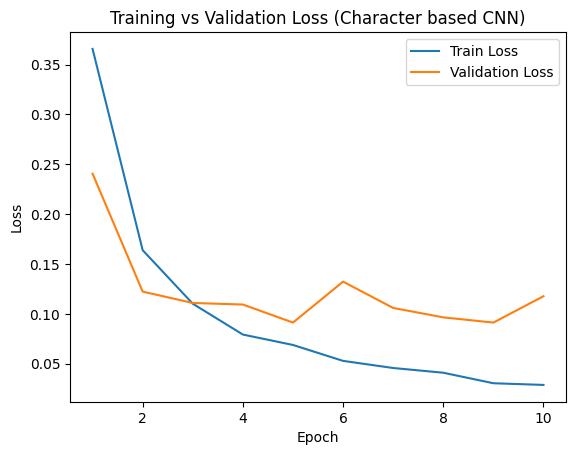

In [48]:
import matplotlib.pyplot as plt
epochs_range = range(1, epochs + 1)

# Accuracy plot
plt.figure()
plt.plot(epochs_range, train_accs, label="Train Accuracy")
plt.plot(epochs_range, valid_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (Character based CNN)")
plt.legend()
plt.show()

# Loss plot
plt.figure()
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, valid_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Character based CNN)")
plt.legend()
plt.show()

Char CNN gives rather good validation accuracy, not sure if it's overfitting. Also this is much faster than transformer (2 min for 10 epoch).

Detect local features in the datasets

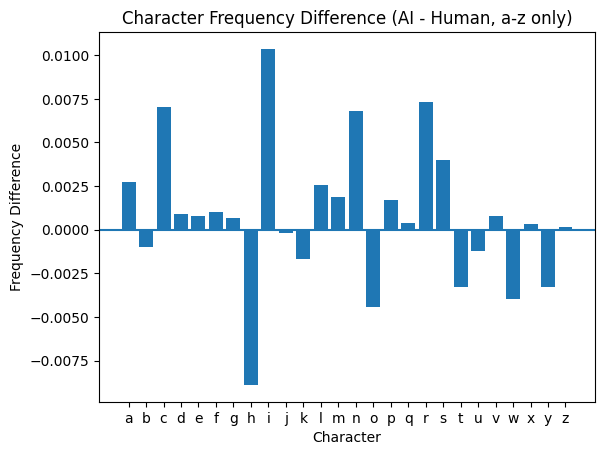

In [49]:
import string

human_texts = data[data["label"] == 0]["clean_text"]
ai_texts = data[data["label"] == 1]["clean_text"]
def char_freq(texts):
    counter = Counter()
    total = 0
    for t in texts:
        counter.update(t)
        total += len(t)
    return {c: counter[c]/total for c in chars}
human_freq = char_freq(human_texts)
ai_freq = char_freq(ai_texts)
letters = list(string.ascii_lowercase)
human_vals_letters = [human_freq.get(c, 0) for c in letters]
ai_vals_letters = [ai_freq.get(c, 0) for c in letters]
diff_vals_letters = np.array(ai_vals_letters) - np.array(human_vals_letters)

plt.figure()
plt.bar(letters, diff_vals_letters)
plt.axhline(0)
plt.title("Character Frequency Difference (AI - Human, a-z only)")
plt.xlabel("Character")
plt.ylabel("Frequency Difference")
plt.show()

In [50]:
from collections import Counter
import pandas as pd

def bigram_freq(texts):
    counter = Counter()
    for t in texts:
        for i in range(len(t)-1):
            counter[t[i:i+2]] += 1
    return counter

human_bigram = bigram_freq(human_texts)
ai_bigram = bigram_freq(ai_texts)

# normalizing
def normalize(counter):
    total = sum(counter.values())
    return {k: v / total for k, v in counter.items()}
human_norm = normalize(human_bigram)
ai_norm = normalize(ai_bigram)
all_bigrams = set(human_norm) | set(ai_norm)
data_rows = []
for bg in all_bigrams:
    h = human_norm.get(bg, 0)
    a = ai_norm.get(bg, 0)
    diff = a - h
    data_rows.append((bg, h, a, diff, abs(diff)))

df = pd.DataFrame(data_rows, columns=[
    "Bigram", "Human_Freq", "AI_Freq", "Diff(AI-Human)", "Abs_Diff"
])

top_k = 10
df_top = df.sort_values("Abs_Diff", ascending=False).head(top_k)
df_top = df_top.sort_values("Diff(AI-Human)", ascending=False)
print(df_top)

    Bigram  Human_Freq   AI_Freq  Diff(AI-Human)  Abs_Diff
555     ti    0.006306  0.010836        0.004529  0.004529
558     es    0.007934  0.011492        0.003557  0.003557
139     ha    0.008439  0.005806       -0.002633  0.002633
473      w    0.011219  0.007634       -0.003585  0.003585
287     ou    0.009887  0.006122       -0.003765  0.003765
673     he    0.018462  0.014296       -0.004166  0.004166
378     th    0.024752  0.019234       -0.005518  0.005518
341      t    0.031826  0.024962       -0.006864  0.006864
683     t     0.020456  0.013275       -0.007181  0.007181
453     e     0.039958  0.032753       -0.007205  0.007205
